# Evaluierung der Few-Shot In-Context Learning Baseline (Decoder-Only)
### Masterarbeit: Automatische Übersetzung von Alltagssprache (AS) in Leichte Sprache (LS)

Dieses Notebook evaluiert **Few-Shot In-Context Learning (ICL)** als reine Prompting-Baseline (ohne Gewichts-Training) auf dem **Lebenshilfe-Testdatensatz** ($N=37$ Praxis-Artikel).

### Wählbare High-Capacity Basismodelle:
- **`Qwen/Qwen2.5-7B-Instruct`:** Global führendes 7B-Modell mit exzellentem Instruction Following.
- **`Vagosolutions/Llama-3-SauerkrautLM-8b-Instruct`:** Auf Deutsch spezialisiertes Llama-3 8B Modell.

---
### Inhaltsübersicht:
1. **Umgebung & Setup:** Robuste Pfade, Hardware-Erkennung & VRAM-Management
2. **Modell- & Tokenizer-Initialisierung:** Laden des gewählten Basismodells
3. **Few-Shot Prompt Engineering:** W1–W11 Systemprompt mit 1:1 Zerlegungs-Demonstrationen
4. **Reward- & Metrik-Setup:** BiLSTM Regressor ($R_{\text{style}}$), Jina SBERT ($R_{\text{sem}}$), LIX und Flesch DE
5. **Batch-Übersetzung** aller 37 Lebenshilfe-Artikel mit Micro-Batching (VRAM-sicher)
6. **Quantitative & Statistische Auswertung** (Mittelwerte, Streuungen, CSV-Export)
7. **Qualitatives Stichproben-Audit:** 1-zu-1 Gegenüberstellung mit der echten menschlichen LS-Referenz
8. **Publikations-Plots:** Boxplots der Stil-, Semantik- und Gesamtmetriken
9. **Interaktiver Live-Übersetzer:** Sofortiger Übersetzungstest für beliebige Eingabetexte

In [1]:
import os
import sys
import re
import json
import math
from typing import List, Dict, Tuple, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModel

# Arbeitsverzeichnis robust auf das Projekt-Root-Verzeichnis setzen
while not (os.path.exists(".git") or os.path.exists("data/corpus")) and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")

if not os.path.exists("data"):
    for candidate in [
        os.path.expanduser("~/master-thesis"),
        "/home/fiete/master-thesis",
        "/home/fisc4884/master-thesis",
        "/Users/fietescheel/Documents/Master Thesis"
    ]:
        if os.path.exists(candidate):
            os.chdir(candidate)
            break

print("Aktuelles Arbeitsverzeichnis:", os.getcwd())
print("Existiert der data-Ordner hier?", os.path.exists("data"))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
torch_dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else (torch.float16 if torch.cuda.is_available() else torch.float32)
print(f"Nutze Device: {DEVICE} | Precision: {torch_dtype}")

# Datei-Pfade
LEBENSHILFE_DATASET = "data/lebenshilfe/lebenshilfe_dataset_clean.json"
REWARD_MODEL_PATH = "results/models/bilstm_mixup_regression.pt" if os.path.exists("results/models/bilstm_mixup_regression.pt") else "results/models/token_length_exp/bilstm_mixup_regression_1024.pt"
REWARD_VOCAB_PATH = "data/vocabs/mixup_vocab.json" if os.path.exists("data/vocabs/mixup_vocab.json") else "data/token_length_exp/mixup_vocab_1024.json"
SBERT_MODEL_NAME = "jinaai/jina-embeddings-v2-base-de"

# FEW-SHOT BASISMODELL (Hier kannst du zwischen Qwen-7B und SauerkrautLM-8B wählen!)
FEW_SHOT_MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"  # Alternative: "Vagosolutions/Llama-3-SauerkrautLM-8b-Instruct"

MAX_SOURCE_LEN = 2048
MAX_TARGET_LEN = 1000

os.makedirs("results/evaluation", exist_ok=True)
os.makedirs("results/plots", exist_ok=True)
print(f"Gewähltes Few-Shot Modell: {FEW_SHOT_MODEL_NAME}")

Aktuelles Arbeitsverzeichnis: /home/fiete/master-thesis
Existiert der data-Ordner hier? True
Nutze Device: cuda | Precision: torch.bfloat16
Gewähltes Few-Shot Modell: Qwen/Qwen2.5-7B-Instruct


## 1. Laden des Few-Shot Basismodells & Tokenizers

Wir laden das unberührte 7B/8B Basismodell mit 16-Bit Precision auf die GPU.

In [2]:
print(f"Lade Tokenizer für {FEW_SHOT_MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(FEW_SHOT_MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

print(f"Lade Basismodell {FEW_SHOT_MODEL_NAME} ({torch_dtype})...")
model = AutoModelForCausalLM.from_pretrained(
    FEW_SHOT_MODEL_NAME,
    torch_dtype=torch_dtype,
    trust_remote_code=True,
    device_map="auto" if torch.cuda.is_available() else None
)
model.eval()
print("Few-Shot Modell & Tokenizer erfolgreich geladen!")

Lade Tokenizer für Qwen/Qwen2.5-7B-Instruct...


`torch_dtype` is deprecated! Use `dtype` instead!


Lade Basismodell Qwen/Qwen2.5-7B-Instruct (torch.bfloat16)...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Few-Shot Modell & Tokenizer erfolgreich geladen!


## 2. Few-Shot In-Context Learning Prompt & Demonstrations

Wir definieren den offiziellen Leichte-Sprache-Systemprompt (W1–W11) und 3 handverlesene 1:1 Demonstrationsbeispiele mit strikter Zerlegung in kurze Hauptsätze und Bindestrich-Setzung.

In [3]:
SYSTEM_PROMPT_LEICHTE_SPRACHE = """Du bist ein professioneller Übersetzer für deutsche Leichte Sprache.
Deine einzige Aufgabe ist es, den gegebenen Ausgangstext Satz für Satz in verständliche Leichte Sprache nach den offiziellen Regeln zu übertragen.

STRIKTE POSITIVE REGELN:
1. Satzbau: Schreibe NUR kurze Hauptsätze (maximal 6 bis 8 Wörter pro Satz). Setze immer einen Punkt.
2. Keine Nebensätze: Zerlege Schachtelsätze und Nebensätze (mit 'wenn', 'weil', 'wie', 'dass') immer in 2 getrennte Hauptsätze.
3. Bindestriche: Nutze bei langen Wörtern Bindestriche (z. B. 'Familien-Mitglieder', 'Arbeits-Tiere', 'Therapie-Hunde').
4. Sprache: Schreibe AUSSCHLIESSLICH auf Deutsch.
5. Strikte Faktentreue: Übersetze NUR die Aussagen des Quelltextes. Erfinde KEINE eigenen Geschichten, Personen oder Beispiele.
6. Ende: Beende die Antwort sofort nach dem letzten Satz des Ausgangstextes."""

USER_INSTRUCTION_PREFIX = "Vereinfache folgenden Text in verständliche deutsche Leichte Sprache:\n\n"

# 1:1 In-Context Demonstrationspaare
FEW_SHOT_EXAMPLES = [
    {
        "as": "Die Bundesregierung hat ein Gesetz zur Stärkung der Barrierefreiheit verabschiedet, wodurch Menschen mit Behinderungen verbesserte Chancen erhalten.",
        "ls": "Die Bundes-Regierung hat ein neues Gesetz gemacht. Das Gesetz stärkt die Barriere-Freiheit. Dadurch bekommen Menschen mit Behinderungen bessere Chancen."
    },
    {
        "as": "Therapiehunde kommen zum Einsatz, wenn Personen schwer erkrankt sind und seelische Unterstützung benötigen.",
        "ls": "Manche Menschen sind schwer krank. Diese Menschen brauchen Unterstützung für die Seele. Deshalb helfen ihnen Therapie-Hunde."
    },
    {
        "as": "Hauskatzen stammen von afrikanischen Wildkatzen ab und haben sich im Laufe von Jahrtausenden an das Zusammenleben mit Menschen angepasst.",
        "ls": "Haus-Katzen stammen von afrikanischen Wild-Katzen ab. Das ist vor vielen tausend Jahren passiert. Die Katzen haben gelernt mit Menschen zusammen zu leben."
    }
]

def create_few_shot_messages(as_text):
    messages = [{"role": "system", "content": SYSTEM_PROMPT_LEICHTE_SPRACHE}]
    for ex in FEW_SHOT_EXAMPLES:
        messages.append({"role": "user", "content": f"{USER_INSTRUCTION_PREFIX}{ex['as']}"})
        messages.append({"role": "assistant", "content": ex["ls"]})
    messages.append({"role": "user", "content": f"{USER_INSTRUCTION_PREFIX}{as_text.strip()}"})
    return messages

def generate_few_shot_batch(texts, batch_size=4, max_new_tokens=768, temperature=0.0):
    model.eval()
    tokenizer.padding_side = "left"
    all_generated = []
    for i in range(0, len(texts), batch_size):
        batch_src = texts[i : i + batch_size]
        formatted_prompts = []
        for t in batch_src:
            msgs = create_few_shot_messages(as_text=t)
            p_str = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
            formatted_prompts.append(p_str)
            
        inputs = tokenizer(formatted_prompts, padding=True, truncation=True, max_length=MAX_SOURCE_LEN, return_tensors="pt").to(DEVICE)
        input_len = inputs["input_ids"].shape[1]
        with torch.no_grad():
            outputs = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs.get("attention_mask"),
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                do_sample=False if temperature == 0.0 else True,
                repetition_penalty=1.2,
                no_repeat_ngram_size=3,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )
        decoded = tokenizer.batch_decode(outputs[:, input_len:], skip_special_tokens=True)
        all_generated.extend([d.strip() for d in decoded])
        del inputs, outputs
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    return all_generated

print("Few-Shot Generierungs-Pipeline bereit!")

Few-Shot Generierungs-Pipeline bereit!


## 3. Reward Evaluator & Metriken (BiLSTM, Jina SBERT, LIX, Flesch DE)

In [4]:
class BiLSTMRegressor(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, dropout=0.3):
        super(BiLSTMRegressor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
        out = self.fc(self.dropout(hidden))
        return self.sigmoid(out).squeeze(-1)

class RewardEvaluator:
    def __init__(self, reward_model_path, reward_vocab_path, sbert_model_name, device="cuda", w_style=0.7, w_sem=0.3):
        self.device = device
        self.w_style = w_style
        self.w_sem = w_sem
        
        raw_state = torch.load(reward_model_path, map_location=device)
        if isinstance(raw_state, dict):
            raw_state = raw_state.get("model_state_dict", raw_state.get("state_dict", raw_state))
        self.ckpt_vocab_size = raw_state["embedding.weight"].shape[0]
        
        self.reward_model = BiLSTMRegressor(self.ckpt_vocab_size, embed_dim=128, hidden_dim=128).to(device)
        self.reward_model.load_state_dict(raw_state)
        self.reward_model.eval()
        print(f"BiLSTM Reward Modell geladen von: {reward_model_path} (Vokabular: {self.ckpt_vocab_size})")
        
        with open(reward_vocab_path, "r", encoding="utf-8") as f:
            vocab_data = json.load(f)
            self.vocab = vocab_data.get("stoi", vocab_data)
        self.unk_idx = self.vocab.get("<unk>") or self.vocab.get("<UNK>") or 1
        
        print(f"Lade SBERT Modell: {sbert_model_name}...")
        self.sbert_tok = AutoTokenizer.from_pretrained(sbert_model_name, trust_remote_code=True)
        self.sbert = AutoModel.from_pretrained(sbert_model_name, trust_remote_code=True).to(device)
        self.sbert.eval()
        print("SBERT Modell erfolgreich geladen!")

    def _tokenize_for_reward(self, texts, max_len=1000):
        ids_list = []
        for t in texts:
            tokens = re.findall(r"\w+|[^\w\s]", str(t).lower())
            ids = [min(self.vocab.get(tok, self.unk_idx), self.ckpt_vocab_size - 1) for tok in tokens[:max_len]]
            ids_list.append(ids if ids else [0])
        mlen = max(len(x) for x in ids_list)
        padded = [x + [0] * (mlen - len(x)) for x in ids_list]
        return torch.tensor(padded, dtype=torch.long, device=self.device)

    def predict_simplicity(self, texts, batch_size=8):
        all_scores = []
        with torch.no_grad():
            for i in range(0, len(texts), batch_size):
                batch_texts = texts[i : i + batch_size]
                inp = self._tokenize_for_reward(batch_texts)
                score = self.reward_model(inp).cpu().numpy()
                if np.isscalar(score) or score.ndim == 0:
                    score = np.array([score])
                all_scores.extend(score.tolist())
                del inp
        return np.array(all_scores)

    def get_embeddings(self, texts, batch_size=4):
        all_embs = []
        with torch.no_grad():
            for i in range(0, len(texts), batch_size):
                batch_texts = texts[i : i + batch_size]
                enc = self.sbert_tok(batch_texts, padding=True, truncation=True, max_length=1024, return_tensors="pt").to(self.device)
                out = self.sbert(**enc)
                mask = enc["attention_mask"].unsqueeze(-1)
                emb = (out.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
                norm_emb = torch.nn.functional.normalize(emb, p=2, dim=1).cpu()
                all_embs.append(norm_emb)
                del enc, out, mask, emb, norm_emb
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
        return torch.cat(all_embs, dim=0)

    def predict_similarity(self, t1, t2):
        e1 = self.get_embeddings(t1, batch_size=4)
        e2 = self.get_embeddings(t2, batch_size=4)
        return (e1 * e2).sum(dim=1).numpy()

    def compute_all_metrics(self, as_texts, ls_preds, ref_texts=None):
        r_style = self.predict_simplicity(ls_preds, batch_size=8)
        r_sem_as = np.clip((self.predict_similarity(as_texts, ls_preds) + 1.0) / 2.0, 0.0, 1.0)
        r_sem_ref = np.clip((self.predict_similarity(ref_texts, ls_preds) + 1.0) / 2.0, 0.0, 1.0) if ref_texts else np.zeros_like(r_style)
        composite = self.w_style * r_style + self.w_sem * r_sem_as
        return r_style, r_sem_as, r_sem_ref, composite

def calculate_lix(text):
    words = re.findall(r"\b\w+\b", text)
    sentences = [s for s in re.split(r"[.!?]+", text) if s.strip()]
    if not words or not sentences:
        return 0.0
    long_words = [w for w in words if len(w) > 6]
    return (len(words) / len(sentences)) + ((len(long_words) * 100) / len(words))

def calculate_flesch_de(text):
    words = re.findall(r"\b\w+\b", text)
    sentences = [s for s in re.split(r"[.!?]+", text) if s.strip()]
    if not words or not sentences:
        return 0.0
    syllables = sum(len(re.findall(r"[aeiouäöüyei+]+|au|eu|äu", w.lower())) or 1 for w in words)
    asl = len(words) / len(sentences)
    asw = syllables / len(words)
    return 180.0 - asl - (58.5 * asw)

print("Initialisiere Reward Evaluator...")
reward_evaluator = RewardEvaluator(REWARD_MODEL_PATH, REWARD_VOCAB_PATH, SBERT_MODEL_NAME, device=DEVICE)
print("Reward Evaluator & Metriken bereit!")

Initialisiere Reward Evaluator...
BiLSTM Reward Modell geladen von: results/models/bilstm_mixup_regression.pt (Vokabular: 19509)
Lade SBERT Modell: jinaai/jina-embeddings-v2-base-de...
SBERT Modell erfolgreich geladen!
Reward Evaluator & Metriken bereit!


## 4. Batch-Generierung & Evaluierung auf dem Lebenshilfe-Datensatz (37 Artikel)

In [5]:
print(f"Lade Testdaten aus {LEBENSHILFE_DATASET}...")
with open(LEBENSHILFE_DATASET, "r", encoding="utf-8") as f:
    lh_data = json.load(f)

print(f"Geladene Artikelpaare: {len(lh_data)}")
as_texts = [d["as_text"] for d in lh_data]
ref_texts = [d["ls_text"] for d in lh_data]
titles = [d.get("title", f"Artikel {i+1}") for i, d in enumerate(lh_data)]

print(f"\nGeneriere Few-Shot Übersetzungen mit {FEW_SHOT_MODEL_NAME}...")
preds_few_shot = generate_few_shot_batch(as_texts, batch_size=2, temperature=0.0)

print("Berechne Reward- und Ähnlichkeitsmetriken...")
r_style, r_sem_as, r_sem_ref, composite = reward_evaluator.compute_all_metrics(as_texts, preds_few_shot, ref_texts)

lix_scores = [calculate_lix(t) for t in preds_few_shot]
flesch_scores = [calculate_flesch_de(t) for t in preds_few_shot]

df_results = pd.DataFrame({
    "title": titles,
    "as_text": as_texts,
    "ls_reference": ref_texts,
    "pred_few_shot": preds_few_shot,
    "simplicity_score": r_style,
    "sbert_sim_to_as": r_sem_as,
    "sbert_sim_to_ref": r_sem_ref,
    "composite_reward": composite,
    "lix_score": lix_scores,
    "flesch_de": flesch_scores,
})

output_csv = "results/evaluation/eval_few_shot_lebenshilfe.csv"
df_results.to_csv(output_csv, index=False, encoding="utf-8")
print(f"\nEvaluierungsergebnisse gespeichert unter: {output_csv}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Lade Testdaten aus data/lebenshilfe/lebenshilfe_dataset_clean.json...
Geladene Artikelpaare: 37

Generiere Few-Shot Übersetzungen mit Qwen/Qwen2.5-7B-Instruct...
Berechne Reward- und Ähnlichkeitsmetriken...

Evaluierungsergebnisse gespeichert unter: results/evaluation/eval_few_shot_lebenshilfe.csv


## 5. Quantitative & Statistische Auswertung

In [6]:
print("=" * 75)
print(f"  📊 FEW-SHOT EVALUIERUNGSERGEBNISSE ({FEW_SHOT_MODEL_NAME})")
print("=" * 75)
print(f"Ø Simplicity-Score (R_style):       {df_results['simplicity_score'].mean():.4f} ± {df_results['simplicity_score'].std():.4f}")
print(f"Ø SBERT-Ähnlichkeit zur AS-Quelle:  {df_results['sbert_sim_to_as'].mean():.4f} ± {df_results['sbert_sim_to_as'].std():.4f}")
print(f"Ø SBERT-Ähnlichkeit zu LS-Referenz: {df_results['sbert_sim_to_ref'].mean():.4f} ± {df_results['sbert_sim_to_ref'].std():.4f}")
print(f"Ø Composite Total Reward:           {df_results['composite_reward'].mean():.4f} ± {df_results['composite_reward'].std():.4f}")
print(f"Ø LIX Lesbarkeitsindex (↓):         {df_results['lix_score'].mean():.2f} ± {df_results['lix_score'].std():.2f}")
print(f"Ø Flesch Reading Ease DE (↑):       {df_results['flesch_de'].mean():.2f} ± {df_results['flesch_de'].std():.2f}")
print("=" * 75)

display(df_results[["simplicity_score", "sbert_sim_to_as", "sbert_sim_to_ref", "composite_reward", "lix_score", "flesch_de"]].describe().round(4))

  📊 FEW-SHOT EVALUIERUNGSERGEBNISSE (Qwen/Qwen2.5-7B-Instruct)
Ø Simplicity-Score (R_style):       0.1932 ± 0.1651
Ø SBERT-Ähnlichkeit zur AS-Quelle:  0.8247 ± 0.0936
Ø SBERT-Ähnlichkeit zu LS-Referenz: 0.8140 ± 0.0927
Ø Composite Total Reward:           0.3826 ± 0.1042
Ø LIX Lesbarkeitsindex (↓):         51.81 ± 71.78
Ø Flesch Reading Ease DE (↑):       41.93 ± 69.10


,simplicity_score,sbert_sim_to_as,sbert_sim_to_ref,composite_reward,lix_score,flesch_de
count,37.0000,37.0000,37.0000,37.0000,37.0000,37.0000
mean,0.1932,0.8247,0.8140,0.3826,51.8071,41.9279
std,0.1651,0.0936,0.0927,0.1042,71.7773,69.1027
min,0.0536,0.5214,0.5009,0.2678,0.0000,-353.5171
25%,0.0939,0.8244,0.7913,0.3218,36.0578,46.5381
50%,0.1291,0.8548,0.8436,0.3449,42.3333,57.9841
75%,0.2348,0.8748,0.8826,0.4202,45.9267,61.4773
max,0.7639,0.9401,0.9122,0.7264,469.9979,74.7277


## 6. Qualitatives Stichproben-Audit (Side-by-Side Textvergleich)

In [7]:
print("=" * 95)
print(f"  🔍 QUALITATIVE STICHPROBEN ({FEW_SHOT_MODEL_NAME})")
print("=" * 95)

for idx in range(min(4, len(df_results))):
    row = df_results.iloc[idx]
    print(f"\n{'='*95}")
    print(f"[ARTIKEL {idx+1}]: {row['title']}")
    print(f"{'='*95}")
    print(f"[AS-Quelle]:\n{row['as_text'][:350]}...")
    print(f"\n[LS-Referenz (Mensch)]:\n{row['ls_reference'][:350]}...")
    print(f"\n[Few-Shot Übersetzung ({FEW_SHOT_MODEL_NAME})]:\n{row['pred_few_shot'][:450]}...")
    print(f"\n-> Scores: Style={row['simplicity_score']:.3f} | SBERT(AS)={row['sbert_sim_to_as']:.3f} | SBERT(Ref)={row['sbert_sim_to_ref']:.3f} | Total={row['composite_reward']:.3f}")
    print("-" * 95)

  🔍 QUALITATIVE STICHPROBEN (Qwen/Qwen2.5-7B-Instruct)

[ARTIKEL 1]: Artikel 1
[AS-Quelle]:
Kiel, 15.10.2020. Arbeit zweiter oder dritter Klasse?? - Positionspapier Die Rede ist in diesemFall von der Entlohnung für Menschen, die in einer Werkstatt (WfbM) arbeiten. Wichtiges Detail: Es sind die Werkstätten selbst, die diese Veränderung dringend fordern. Der Lohn der Mitarbeiter*innen mit Werkstattvertrag ist bei einem 6 – 8 Stunden Arbeits...

[LS-Referenz (Mensch)]:
Positionspapier: Bildung und Teilhabe am Arbeitsleben für Alle in einem inklusiven Arbeitsmarkt. Positionspapier bedeutet: Mehrere Gruppen haben diesen Text geschrieben. Sie haben Ihre Meinung aufgeschrieben. Und sie haben Ihre Ideen aufgeschrieben. Diese Meinungen und Ideen heißen auch: Positionen zum Thema. Die Positionen sollen viele Menschen le...

[Few-Shot Übersetzung (Qwen/Qwen2.5-7B-Instruct)]:
In Kiel am 19. Oktober 2019 wurde etwas besprochen. Man sprach darüber, wie Menschen bezahlt werden sollen, die an Werkstat

## 7. Visualisierung der Metrik-Verteilungen

Plot gespeichert unter: results/plots/few_shot_lebenshilfe_metrics.png


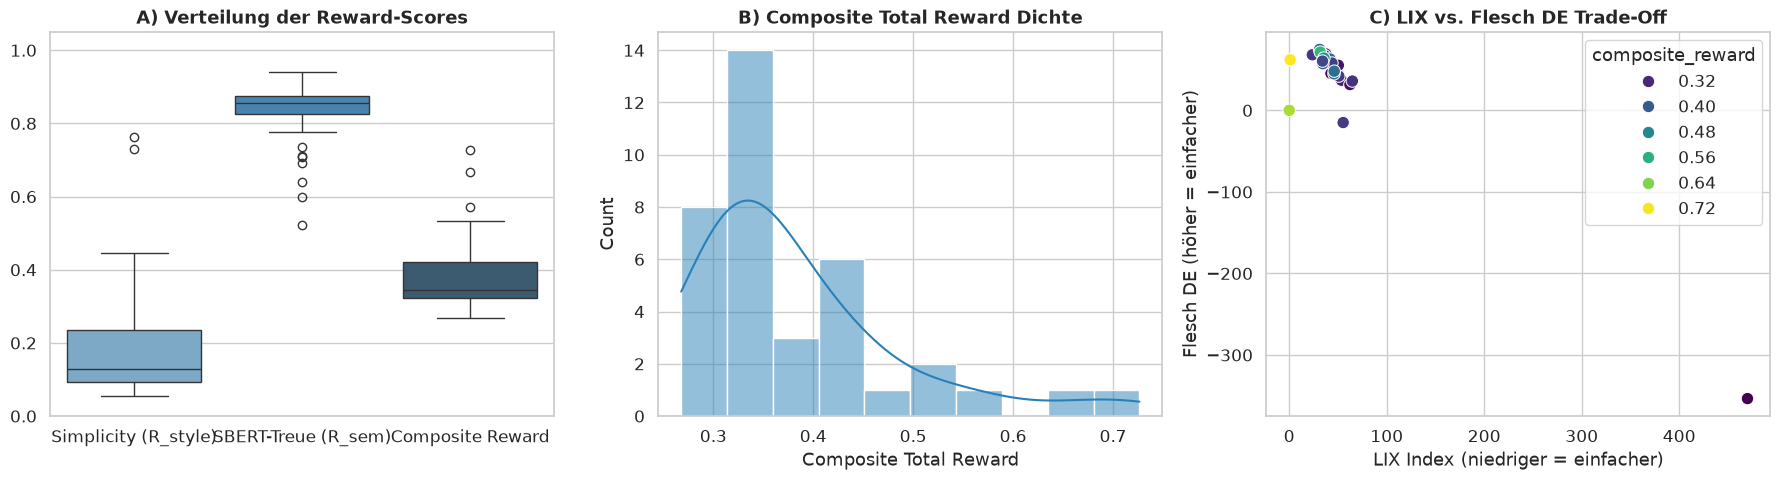

In [8]:
sns.set_theme(style="whitegrid", font_scale=1.1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Boxplot der Kern-Metriken
df_box = pd.DataFrame({
    "Simplicity (R_style)": df_results["simplicity_score"],
    "SBERT-Treue (R_sem)": df_results["sbert_sim_to_as"],
    "Composite Reward": df_results["composite_reward"]
})
sns.boxplot(ax=axes[0], data=df_box, palette="Blues_d")
axes[0].set_title("A) Verteilung der Reward-Scores", fontweight="bold")
axes[0].set_ylim(0, 1.05)

# 2. Histogramm Composite Reward
sns.histplot(ax=axes[1], data=df_results["composite_reward"], kde=True, color="#2980b9", bins=10)
axes[1].set_title("B) Composite Total Reward Dichte", fontweight="bold")
axes[1].set_xlabel("Composite Total Reward")

# 3. Lesbarkeits-Metriken
sns.scatterplot(ax=axes[2], data=df_results, x="lix_score", y="flesch_de", hue="composite_reward", palette="viridis", s=80)
axes[2].set_title("C) LIX vs. Flesch DE Trade-Off", fontweight="bold")
axes[2].set_xlabel("LIX Index (niedriger = einfacher)")
axes[2].set_ylabel("Flesch DE (höher = einfacher)")

plt.tight_layout()
plot_path = "results/plots/few_shot_lebenshilfe_metrics.png"
plt.savefig(plot_path, dpi=300)
print(f"Plot gespeichert unter: {plot_path}")
plt.show()

## 8. Interaktiver Live-Übersetzungstest

Hier kannst du jeden beliebigen deutschen Text live mit dem gewählten Few-Shot Modell übersetzen.

In [9]:
def translate_few_shot_interactive(text: str, temperature: float = 0.0):
    print("=" * 85)
    print("[EINGABETEXT (AS)]:")
    print(text.strip())
    print("=" * 85)
    
    pred = generate_few_shot_batch([text], temperature=temperature)[0]
    r_style, r_sem_as, _, comp = reward_evaluator.compute_all_metrics([text], [pred])
    lix = calculate_lix(pred)
    flesch = calculate_flesch_de(pred)
    
    print(f"\n[FEW-SHOT ÜBERSETZUNG ({FEW_SHOT_MODEL_NAME})]:")
    print(pred)
    print(f"\n[Scores]: Simplicity={r_style[0]:.3f} | SBERT(AS)={r_sem_as[0]:.3f} | Total={comp[0]:.3f} | LIX={lix:.1f} | Flesch={flesch:.1f}")
    print("=" * 85)

# Testbeispiel:
sample_input = """Hunde (Canis lupus familiaris) begleiten den Menschen seit Jahrtausenden und gelten als das älteste domestizierte Haustier. Sie stammen vom Wolf ab und haben sich im Laufe der Zeit perfekt an das Leben mit uns angepasst. Heute sind sie nicht nur beliebte Haustiere, sondern oft vollwertige Familienmitglieder, ausdauernde Arbeitstiere und therapeutische Helfer."""

translate_few_shot_interactive(sample_input, temperature=0.0);

[EINGABETEXT (AS)]:
Hunde (Canis lupus familiaris) begleiten den Menschen seit Jahrtausenden und gelten als das älteste domestizierte Haustier. Sie stammen vom Wolf ab und haben sich im Laufe der Zeit perfekt an das Leben mit uns angepasst. Heute sind sie nicht nur beliebte Haustiere, sondern oft vollwertige Familienmitglieder, ausdauernde Arbeitstiere und therapeutische Helfer.

[FEW-SHOT ÜBERSETZUNG (Qwen/Qwen2.5-7B-Instruct)]:
Hundeleben (Cani lupus familiaris) begleitung des Menschen seit langer zeit. Sie sind das ältesten zahme Haus-Tiere. Hunde entstammten vom wolf. Über viele jahrhundert haben sie sich gut an unser leben angepasste. Heutzutage sind hunde beliebt Haus-Tieren. Manchmal sind sie auch wichtige Familientiere, arbeitstiere oder hilfreich für therapie.

[Scores]: Simplicity=0.446 | SBERT(AS)=0.914 | Total=0.587 | LIX=40.8 | Flesch=54.8
